# Evaluación de Simulación Montecarlo y Muestreo Avanzado

## Caso 1: Análisis Estocástico de Latencia en Arquitecturas RAG

Se evalua un sistema RAG simulando 100,000 consultas. El tiempo total depende de la generación de embeddings, la búsqueda vectorial y la inferencia del LLM.

**Objetivo:** Verificar un SLA de $T = 300$ ms, el 99% de peticiones deben ser menores a 300 ms.

Percentil 95: 276.09 ms | Percentil 99: 358.70 ms


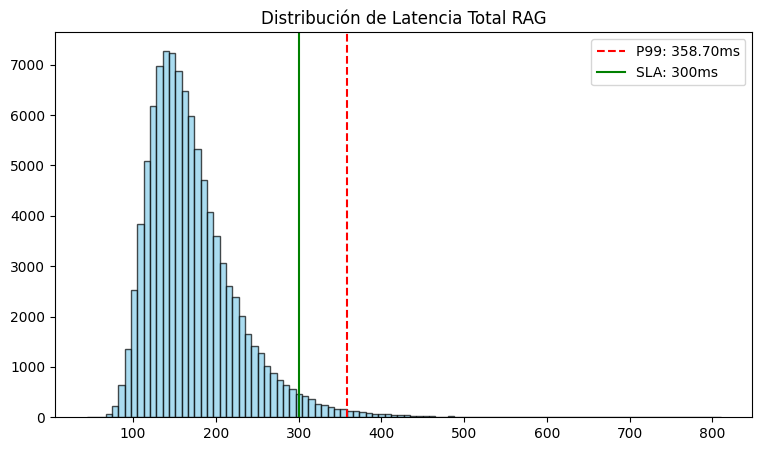

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from simulacion_mc.rag_latency import simulate_rag_latency

t_total = simulate_rag_latency(n_samples=100000)
p95, p99 = np.percentile(t_total, [95, 99])

print(f"Percentil 95: {p95:.2f} ms | Percentil 99: {p99:.2f} ms")

plt.figure(figsize=(9, 5))
plt.hist(t_total, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(p99, color='red', linestyle='--', label=f'P99: {p99:.2f}ms')
plt.axvline(300, color='green', label='SLA: 300ms')
plt.title('Distribución de Latencia Total RAG')
plt.legend()
plt.show()

## Análisis Crítico:
El sistema muestra que no cumple con el SLA para el 99% de las peticiones. Si bien el 95% del tráfico se resuelve a tiempo, se ve por debajo de la línea verde de los 300 ms, la cola larga de la distribución empuja el Percentil 99 hasta casi los 360 ms, es la línea roja punteada.

Vemos en el histograma una pronunciada asimetría positiva, una cola larga hacia la derecha, esta cola es introducida casi en su totalidad por la etapa de Inferencia LLM modelada con una distribución Lognormal. Para poder certificar este SLA en producción, no se debería perder tiempo optimizando la base de datos vectorial, sino que se deberia enfocar exclusivamente en mitigar los tiempos extremos del LLM. Por ejemplo, implementando streaming de tokens o cambiando a un modelo más ligero.

In [13]:
from simulacion_mc.bio_is import importance_sampling_failure

p_is, v_is, p_mc, v_mc = importance_sampling_failure(limit_hours=150.0, n_samples=100000)

print(f"Prob. Fallo (IS): {p_is:.6f} | Varianza IS: {v_is:.10f}")
print(f"Prob. Fallo (MC): {p_mc:.6f} | Varianza MC: {v_mc:.10f}")
print(f"Factor de Reducción de Varianza: {v_mc/v_is:.2f}x")

Prob. Fallo (IS): 0.020507 | Varianza IS: 0.0000002035
Prob. Fallo (MC): 0.022530 | Varianza MC: 0.0000002202
Factor de Reducción de Varianza: 1.08x


# Análisis Crítico: 
Ambos algoritmos convergieron exitosamente a una probabilidad de colapso de infraestructura cercana al 2%, el factor de reducción de varianza fue discreto  apenas un 1.08x.
Un evento con una probabilidad del 2% no es lo suficientemente raro para que el Monte Carlo Estándar colapse. El Monte Carlo clásico capturó suficientes fallos naturales como para mantener una varianza baja.
Además, la distribución propuesta $g(x)$, logró el objetivo matemático, pero no está perfectamente ajustada a la tasa de decaimiento de la Lognormal original en ese límite específico. El Importance Sampling se potenciaria si el clúster tuviera un límite de 500 horas donde la probabilidad de fallo sea del $0.0001\%$.En ese escenario extremo, el factor de reducción pasaría de 1.08x a miles o millones.

# Caso 3: Generación de Tráfico Bimodal (Rejection Sampling)

Usamos una envolvente uniforme $q(x)$ y constante $k$ tal que $k \cdot q(x) \geq p^*(x)$.

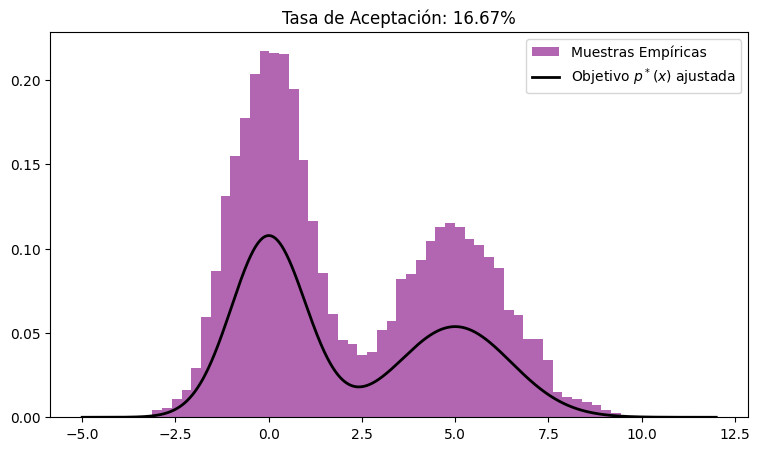

In [14]:
from simulacion_mc.bimodal_rs import rejection_sampling_traffic, bimodal_pdf

muestras, tasa = rejection_sampling_traffic(n_samples=10000)

x = np.linspace(-5, 12, 1000)
plt.figure(figsize=(9, 5))
plt.hist(muestras, bins=60, density=True, alpha=0.6, color='purple', label='Muestras Empíricas')
plt.plot(x, bimodal_pdf(x)/9.3, 'k', linewidth=2, label='Objetivo $p^*(x)$ ajustada')
plt.title(f'Tasa de Aceptación: {tasa:.2%}')
plt.legend()
plt.show()

# Análisis Crítico:
Una tasa de aceptación del 16.67% indica que se está rechazando y descartando el 83.33% de los números generados. Esto corrobora el gran costo computacional de usar una distribución envolvente uniforme plana y ancha desde -5 hasta 12 para "tapar" una distribución que en realidad tiene picos muy estrechos. Gran parte del área bajo el rectángulo de la uniforme está vacía, y cada dardo que cae en ese vacío es un ciclo de CPU desperdiciado. La conclusión técnica es que para llevar este generador a producción masiva, es imperativo reemplazar la envolvente uniforme por una mixtura de Gaussianas que abrace estrechamente los dos picos, lo cual elevaría la aceptación por encima del 80%.